For the past five years, you've honed your skills as a Senior Data Scientist for a global university. Your team leverages its data analytics and machine learning skill sets to help other departments make data-driven decisions. One such department is the procurement team, who is trying to decide the best new mobile phone to offer to the university's employees. For the last week, a Junior Data Scientist on your team has been developing a workflow to help provide insight to the procurement team. You will be reviewing their code to ensure it's ready to ship to production. 

The first chunk of code that you'll be reviewing is your colleague's function to prepare smartphone data from a CSV file for visualization. After ingesting and cleaning the smartphone data, your colleague has prepared a function to plot a variable passed to the function, versus `"price"`. However, within this function, there is code that does not adhere to DRY principles and is copied and pasted. Make sure to refactor the code appropriately, using the `column_to_label()` function defined below.

Wow, your colleague even included a unit test to ensure `NaN` values were removed from the cleaned DataFrame! However, it doesn't seem like the unit test is passing when executed. Re-work this unit test to ensure that it matches the transformation logic in the `prepare_smartphone_data()` function.

Once you've made changes to the `test_nan_values` unit test, you'll want to ensure that these unit tests execute with `ExitCode.OK`. This means that the `pytest` defined above has passed testing, and the code is one step closer to being to be shipped to production.

For context, there is a print statement in the `prepare_smartphone_data()` function in the first cell of the notebook below that can be used to visualize the dataset your Junior Data Engineer has been working with. Feel free to update this line of code as needed. This can then be removed after the dataset has been investigated. Best of luck!

In [1]:
# cell 1: data preparation

import os
from typing import Optional
import pandas as pd


def prepare_smartphone_data(file_path: str, show_preview: bool = True) -> pd.DataFrame:
    """
    Read and prepare smartphone data for visualization.

    Transformations applied:
        - Keep required columns.
        - Drop records missing 'battery_capacity' or 'os'.
        - Convert price from cents to dollars.

    :param file_path: Path to smartphone CSV file
    :param show_preview: If True, prints the cleaned dataset head
    :return: Cleaned smartphone DataFrame
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"File containing smartphone data not found at path: {file_path}"
        )

    raw_data = pd.read_csv(file_path)

    columns_to_keep = [
        "brand_name",
        "os",
        "price",
        "avg_rating",
        "processor_speed",
        "battery_capacity",
        "screen_size",
    ]

    trimmed_data = raw_data.loc[:, columns_to_keep].copy()

    cleaned_data = trimmed_data.dropna(subset=["battery_capacity", "os"]).copy()

    cleaned_data.loc[:, "price"] = cleaned_data["price"] / 100

    # Only print during interactive use, never during tests
    if show_preview:
        print("📌 Cleaned Smartphone Data Preview:")
        print(cleaned_data.head())

    return cleaned_data


# Call the function normally (preview ON)
cleaned_data = prepare_smartphone_data("./data/smartphones.csv")


📌 Cleaned Smartphone Data Preview:
   brand_name   os    price  avg_rating  processor_speed  battery_capacity  \
0       apple  ios   389.99         7.3             2.65            3110.0   
1       apple  ios   469.99         7.5             2.65            3110.0   
2       apple  ios  1099.00         7.7             2.65            3500.0   
11      apple  ios   629.99         7.9             3.22            3240.0   
12      apple  ios   729.99         7.9             3.22            3240.0   

    screen_size  
0           6.1  
1           6.1  
2           6.5  
11          6.1  
12          6.1  


C:\Users\lexha\AppData\Local\Temp\ipykernel_13884\816176533.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 389.99  469.99 1099.    629.99  729.99  919.99  649.   1199.   1479.
 1299.   1299.   1799.   1399.    659.99  759.99  959.99  699.9   749.99
  849.99 1049.99 1199.9  1729.99 1299.9  1299.9  1829.99 1399.9  1699.
  829.9   849.9  1429.9  1499.    529.9   299.9   399.    719.99  399.99
  719.99  729.99  899.99  759.9   639.9    89.9   149.9   149.99  149.99
  459.99   99.9    61.9    69.99   74.99  159.9   159.99  201.2   360.
  329.99  404.8   543.    797.    299.99  531.    819.99  349.9   539.9
  709.9   329.9   249.9   399.9   309.9   549.9   949.9    99.99  139.99
  139.99  169.99  149.9   169.99  279.99  109.49 2149.9   699.9   999.9
 2399.99  299.9   239.99  219.9   299.9   199.9   219.9   229.9   829.9
  609.99   67.99   79.99   80.99   96.9    99.99   89.1   108.5   123.4
  179.99  199.99   89.

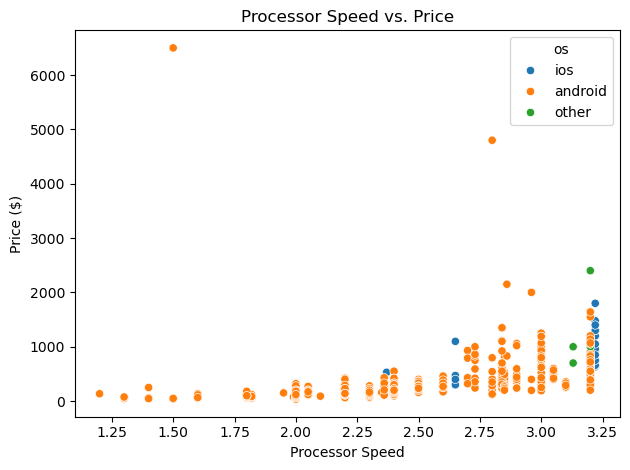

In [2]:
# cell 2: helper + visualization

import seaborn as sns
import matplotlib.pyplot as plt


def column_to_label(column_name: str) -> str:
    """
    Convert a dataframe column name to a nicely formatted label for plots.
    Example: 'processor_speed' -> 'Processor Speed'
    """
    if not isinstance(column_name, str):
        raise TypeError("Please pass a string for 'column_name'.")

    return " ".join(column_name.split("_")).title()


def visualize_versus_price(clean_data, x: str) -> None:
    """
    Plot the relationship between a chosen variable (x) and price.

    :param clean_data: DataFrame with cleaned smartphone data.
    :param x: Column name used for the x-axis.
    """
    # Convert column name into a nice label
    label = column_to_label(x)

    # Create scatterplot
    sns.scatterplot(x=x, y="price", data=clean_data, hue="os")

    # Labels and title
    plt.xlabel(label)
    plt.ylabel("Price ($)")
    plt.title(f"{label} vs. Price")

    # 👇 Ensure the chart ALWAYS displays
    plt.tight_layout()
    plt.show()


# 👇 CALL THE FUNCTION SO THE PLOT DISPLAYS

visualize_versus_price(cleaned_data, "processor_speed")


In [3]:
# cell 3: unit tests
import pytest
import ipytest

ipytest.config.rewrite_asserts = True
__file__ = "notebook.ipynb"


@pytest.fixture()
def clean_smartphone_data():
    # Disable preview during tests
    return prepare_smartphone_data("./data/smartphones.csv", show_preview=False)


def test_nan_values(clean_smartphone_data):
    """
    Test that there are no NaN values in 'battery_capacity' or 'os'
    """
    assert clean_smartphone_data["battery_capacity"].isnull().sum() == 0
    assert clean_smartphone_data["os"].isnull().sum() == 0


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.13.9, pytest-8.4.2, pluggy-1.5.0 -- C:\Users\lexha\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\lexha\Downloads\DataCamp\Performing a Code Review\workspace
plugins: anyio-4.10.0
collecting ... collected 1 item

t_36bd7ba495c4423e8d2a0af8a1168036.py::test_nan_values <- ..\..\..\..\AppData\Local\Temp\ipykernel_13884\1216516284.py PASSED [100%]

======================================== warnings summary =========================================
t_36bd7ba495c4423e8d2a0af8a1168036.py::test_nan_values
  C:\Users\lexha\AppData\Local\Temp\ipykernel_13884\816176533.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 389.99  469.99 1099.    629.99  729.99  919.99  649.   1199.   1479.
   1299.   1299.   1799.   1399.    659.99  759.99  959.99  699.9   749.99
    849.99 1049.99 119

<ExitCode.OK: 0>